# Model Engineering : Prédiction du défaut de paiement

Cette partie reprend les sorties de la phase d'exploration / feature engineering et met en place une démarche **MLOps** pour comparer plusieurs modèles de classification.

## Objectifs de cette section
- charger les données prétraitées de façon robuste ;
- séparer proprement les jeux d'entraînement et de test avec `stratify` ;
- comparer **3 algorithmes de classification** (Régression Logistique, Arbre de Décision, Random Forest) ;
- faire une **validation croisée** ;
- lancer une **recherche d'hyperparamètres** ;
- **tracker chaque modèle avec MLflow** en respectant la consigne :
  - **1 modèle = 1 experiment**
  - **1 itération = 1 run**
- sélectionner le meilleur modèle selon des métriques adaptées au risque bancaire ;
- sauvegarder les artefacts nécessaires au déploiement.

## 0. Imports, configuration et reproductibilité

On fixe un `random_state` unique pour assurer la reproductibilité.  
Le tracking MLflow est configuré localement dans un dossier `mlruns`.

In [40]:
import warnings
warnings.filterwarnings("default", category=UserWarning)
warnings.filterwarnings("ignore", message=".*tight_layout.*")

from pathlib import Path
import json
import subprocess
import sys
import time
import socket
import webbrowser
import tempfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    make_scorer
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

PROJECT_ROOT = Path.cwd().resolve()
MLRUNS_DIR = (PROJECT_ROOT / "mlruns").resolve()
ARTIFACTS_DIR = (PROJECT_ROOT / "artifacts").resolve()

MLRUNS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"file:{MLRUNS_DIR}")

print("Project root     :", PROJECT_ROOT)
print("MLflow tracking  :", MLRUNS_DIR)
print("Artifacts folder :", ARTIFACTS_DIR)
print("Random state     :", RANDOM_STATE)

Project root     : C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\models
MLflow tracking  : C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\models\mlruns
Artifacts folder : C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\models\artifacts
Random state     : 42


## 1. Chargement robuste des données

On essaie plusieurs chemins possibles pour éviter qu'un simple changement d'arborescence casse le notebook.
Les fichiers attendus sont :
- `X_scaled.npy`
- `y.npy`
- éventuellement `Loan_Data_clean.csv` pour récupérer les noms de variables

In [41]:
def resolve_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate).resolve()
        if path.exists():
            return path
    return None

x_candidates = [
    "../data/X_scaled.npy",
    "X_scaled.npy",
    "../X_scaled.npy",
    "/content/X_scaled.npy"
]

y_candidates = [
    "../data/y.npy",
    "y.npy",
    "../y.npy",
    "/content/y.npy"
]

clean_csv_candidates = [
    "../data/Loan_Data_clean.csv",
    "Loan_Data_clean.csv",
    "../Loan_Data_clean.csv",
    "/content/Loan_Data_clean.csv"
]

x_path = resolve_existing_path(x_candidates)
y_path = resolve_existing_path(y_candidates)
clean_csv_path = resolve_existing_path(clean_csv_candidates)

if x_path is None or y_path is None:
    raise FileNotFoundError(
        "Impossible de trouver X_scaled.npy et/ou y.npy. "
        "Place les fichiers exportés par Pauline dans ../data/ "
        "ou dans le même dossier que ce notebook."
    )

X = np.load(x_path)
y = np.load(y_path)

feature_names = None
if clean_csv_path is not None:
    df_clean = pd.read_csv(clean_csv_path)
    if "default" in df_clean.columns:
        candidate_features = [col for col in df_clean.columns if col != "default"]
        if len(candidate_features) == X.shape[1]:
            feature_names = candidate_features

if feature_names is None:
    feature_names = [f"feature_{i}" for i in range(X.shape[1])]

X_df = pd.DataFrame(X, columns=feature_names)
y_series = pd.Series(y, name="default")

print("X path :", x_path)
print("y path :", y_path)
print("clean csv path :", clean_csv_path if clean_csv_path is not None else "non trouvé")
print("\nShape X :", X_df.shape)
print("Shape y :", y_series.shape)
print("\nDistribution de la cible :")
display(y_series.value_counts().rename("count").to_frame())
print("\nProportion de défaut :")
display((y_series.value_counts(normalize=True) * 100).round(2).rename("pct").to_frame())

X path : C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\data\X_scaled.npy
y path : C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\data\y.npy
clean csv path : non trouvé

Shape X : (10000, 4)
Shape y : (10000,)

Distribution de la cible :


,count
default,
0,8149
1,1851



Proportion de défaut :


,pct
default,
0,81.49
1,18.51


## 2. Contrôles qualité avant modélisation

Avant d'entraîner les modèles, on vérifie :
- les valeurs manquantes ;
- les doublons ;
- le déséquilibre de la cible ;
- la cohérence des dimensions.

In [42]:
print("Valeurs manquantes dans X :", int(X_df.isna().sum().sum()))
print("Doublons dans X           :", int(X_df.duplicated().sum()))
print("Valeurs uniques de y      :", sorted(y_series.unique().tolist()))
print("Taille dataset            :", X_df.shape)

assert len(X_df) == len(y_series), "X et y n'ont pas la même taille."
assert set(y_series.unique()).issubset({0, 1}), "La cible doit être binaire (0/1)."

Valeurs manquantes dans X : 0
Doublons dans X           : 0
Valeurs uniques de y      : [0, 1]
Taille dataset            : (10000, 4)


## 3. Split train / test

Le `stratify=y` est **obligatoire** ici pour préserver la distribution de la classe défaut sur les jeux train et test.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df,
    y_series,
    test_size=TEST_SIZE,
    stratify=y_series,
    random_state=RANDOM_STATE
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

train_default_rate = y_train.mean()
test_default_rate = y_test.mean()
print(f"\nTaux de défaut train : {train_default_rate:.4f}")
print(f"Taux de défaut test  : {test_default_rate:.4f}")

Train : (8000, 4) (8000,)
Test  : (2000, 4) (2000,)

Taux de défaut train : 0.1851
Taux de défaut test  : 0.1850


## 4. Stratégie d'évaluation

Pour un problème de défaut bancaire, l'accuracy seule n'est pas suffisante.

Les métriques suivies sont :
- **ROC-AUC** : capacité de séparation globale ;
- **PR-AUC** : pertinente si la classe défaut est minoritaire ;
- **Recall** : important pour détecter un maximum de défauts ;
- **Precision** : utile pour limiter les faux positifs ;
- **F1-score** : compromis précision / rappel ;
- **Accuracy** : donnée à titre indicatif.

In [44]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "accuracy": make_scorer(accuracy_score),
}

print(cv)
print("Scoring keys :", list(scoring.keys()))

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Scoring keys : ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'accuracy']


## 5. Définition des modèles et des grilles d'hyperparamètres

On teste **3 modèles demandés** :
1. Régression Logistique
2. Arbre de Décision
3. Random Forest

Chaque modèle est encapsulé dans un `Pipeline` avec un `SimpleImputer` pour rendre la chaîne de traitement plus robuste en cas de valeurs manquantes.

In [45]:
model_configs = {
    "logistic_regression": {
        "pipeline": Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE
                ))
            ]
        ),
        "param_grid": {
            "model__C": [0.01, 0.1, 1.0, 10.0],
            "model__solver": ["lbfgs", "liblinear"]
        }
    },
    "decision_tree": {
        "pipeline": Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", DecisionTreeClassifier(
                    class_weight="balanced",
                    random_state=RANDOM_STATE
                ))
            ]
        ),
        "param_grid": {
            "model__max_depth": [3, 5, 8, 12, None],
            "model__min_samples_split": [2, 10, 20, 50],
            "model__min_samples_leaf": [1, 5, 10, 20]
        }
    },
    "random_forest": {
        "pipeline": Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                ))
            ]
        ),
        "param_grid": {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [5, 8, 12, None],
            "model__min_samples_split": [2, 10, 20],
            "model__min_samples_leaf": [1, 5, 10]
        }
    }
}

list(model_configs.keys())

['logistic_regression', 'decision_tree', 'random_forest']

## 6. Fonctions utilitaires : évaluation, MLflow et entraînement

La logique ci-dessous garantit :
- une **validation croisée** avant test final ;
- un **run baseline** ;
- un **run tuned** avec `GridSearchCV` ;
- le logging MLflow des paramètres, métriques et artefacts.

In [46]:
def compute_test_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)

    metrics = {
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if y_proba is not None:
        metrics["test_roc_auc"] = roc_auc_score(y_test, y_proba)
        metrics["test_pr_auc"] = average_precision_score(y_test, y_proba)

    return metrics, y_pred, y_proba


def run_cv(model, X_train, y_train, scoring, cv):
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False
    )

    summary = {}
    for metric_name in scoring.keys():
        values = cv_results[f"test_{metric_name}"]
        summary[f"cv_mean_{metric_name}"] = float(np.mean(values))
        summary[f"cv_std_{metric_name}"] = float(np.std(values))
    return summary


def log_dict_to_mlflow(data, prefix=None):
    for key, value in data.items():
        if isinstance(value, (np.floating, np.integer)):
            value = value.item()

        full_key = f"{prefix}_{key}" if prefix else key

        if isinstance(value, (int, float, bool)):
            mlflow.log_param(full_key, value)
        elif value is None:
            mlflow.log_param(full_key, "None")
        elif isinstance(value, str):
            mlflow.log_param(full_key, value)
        else:
            mlflow.log_param(full_key, json.dumps(value, default=str))


def create_eval_artifacts(model, X_test, y_test, model_name, run_type):
    run_artifact_dir = ARTIFACTS_DIR / "mlflow_eval" / model_name / run_type
    run_artifact_dir.mkdir(parents=True, exist_ok=True)

    y_pred = model.predict(X_test)
    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    created_files = []

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
    ax.set_title(f"Confusion Matrix - {model_name} ({run_type})")
    fig.tight_layout()
    cm_path = run_artifact_dir / "confusion_matrix.png"
    fig.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    created_files.append(cm_path)

    if y_score is not None:
        fig, ax = plt.subplots(figsize=(5, 4))
        RocCurveDisplay.from_predictions(y_test, y_score, ax=ax)
        ax.set_title(f"ROC Curve - {model_name} ({run_type})")
        fig.tight_layout()
        roc_path = run_artifact_dir / "roc_curve.png"
        fig.savefig(roc_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        created_files.append(roc_path)

        fig, ax = plt.subplots(figsize=(5, 4))
        PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=ax)
        ax.set_title(f"PR Curve - {model_name} ({run_type})")
        fig.tight_layout()
        pr_path = run_artifact_dir / "precision_recall_curve.png"
        fig.savefig(pr_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        created_files.append(pr_path)

    # Feature importance for tree-based models
    final_estimator = model.named_steps.get("model") if hasattr(model, "named_steps") else model
    if hasattr(final_estimator, "feature_importances_"):
        importances = pd.Series(final_estimator.feature_importances_, index=X_test.columns).sort_values(ascending=False).head(15)
        fig, ax = plt.subplots(figsize=(7, 5))
        importances.sort_values().plot(kind="barh", ax=ax)
        ax.set_title(f"Top 15 Feature Importances - {model_name} ({run_type})")
        ax.set_xlabel("Importance")
        fig.tight_layout()
        fi_path = run_artifact_dir / "feature_importances.png"
        fig.savefig(fi_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        created_files.append(fi_path)

    return created_files


def log_model_with_metadata(model, X_reference, model_name):
    input_example = X_reference.head(5)
    signature = infer_signature(X_reference, model.predict(X_reference))
    mlflow.sklearn.log_model(
        sk_model=model,
        name="model",
        signature=signature,
        input_example=input_example
    )


def train_and_track_model(model_name, config, X_train, y_train, X_test, y_test, scoring, cv):
    experiment_name = f"credit_default_{model_name}"
    mlflow.set_experiment(experiment_name)

    pipeline = config["pipeline"]
    param_grid = config["param_grid"]

    # ---------------------------
    # Run 1: baseline
    # ---------------------------
    with mlflow.start_run(run_name=f"{model_name}_baseline") as baseline_run:
        mlflow.set_tags({
            "model_name": model_name,
            "run_type": "baseline",
            "workflow_stage": "model_engineering",
            "project": "credit_default_mlops",
            "dataset_source": "preprocessed_features_from_exploration"
        })

        baseline_cv = run_cv(pipeline, X_train, y_train, scoring, cv)
        pipeline.fit(X_train, y_train)
        baseline_test_metrics, _, _ = compute_test_metrics(pipeline, X_test, y_test)

        mlflow.log_param("grid_scoring", "not_applicable")
        log_dict_to_mlflow(pipeline.get_params(), prefix="param")
        mlflow.log_metrics(baseline_cv)
        mlflow.log_metrics(baseline_test_metrics)

        for artifact_path in create_eval_artifacts(pipeline, X_test, y_test, model_name, "baseline"):
            mlflow.log_artifact(str(artifact_path), artifact_path="evaluation")

        log_model_with_metadata(pipeline, X_train, model_name)

    # ---------------------------
    # Run 2: tuning
    # ---------------------------
    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    tuned_cv = run_cv(best_model, X_train, y_train, scoring, cv)
    tuned_test_metrics, tuned_pred, tuned_proba = compute_test_metrics(best_model, X_test, y_test)

    with mlflow.start_run(run_name=f"{model_name}_tuned") as tuned_run:
        mlflow.set_tags({
            "model_name": model_name,
            "run_type": "tuned",
            "workflow_stage": "model_engineering",
            "project": "credit_default_mlops",
            "selection_metric": "roc_auc"
        })

        mlflow.log_param("grid_scoring", "roc_auc")
        log_dict_to_mlflow(grid.best_params_, prefix="best_param")
        mlflow.log_metric("grid_best_score_roc_auc", float(grid.best_score_))
        mlflow.log_metrics(tuned_cv)
        mlflow.log_metrics(tuned_test_metrics)

        for artifact_path in create_eval_artifacts(best_model, X_test, y_test, model_name, "tuned"):
            mlflow.log_artifact(str(artifact_path), artifact_path="evaluation")

        log_model_with_metadata(best_model, X_train, model_name)

    result_row = {
        "model": model_name,
        "experiment_name": experiment_name,
        "best_params": grid.best_params_,
        "grid_best_score_roc_auc": float(grid.best_score_),
        **tuned_cv,
        **tuned_test_metrics
    }

    artifacts = {
        "best_model": best_model,
        "y_pred": tuned_pred,
        "y_proba": tuned_proba,
        "grid_search": grid
    }

    return result_row, artifacts


def is_port_open(host="127.0.0.1", port=5000):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.settimeout(1)
        return sock.connect_ex((host, port)) == 0


def launch_mlflow_ui(tracking_dir=MLRUNS_DIR, port=5000, auto_open=True):
    """
    Lance MLflow UI en arrière-plan et ouvre automatiquement le navigateur.
    À exécuter après les runs MLflow.
    """
    tracking_dir = Path(tracking_dir).resolve()
    backend_uri = tracking_dir.as_uri()

    if is_port_open(port=port):
        url = f"http://127.0.0.1:{port}"
        print(f"MLflow UI semble déjà actif : {url}")
        if auto_open:
            webbrowser.open(url, new=2)
        return None, url

    cmd = [
        sys.executable,
        "-m",
        "mlflow",
        "ui",
        "--backend-store-uri",
        backend_uri,
        "--port",
        str(port),
    ]

    process = subprocess.Popen(
        cmd,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        cwd=str(PROJECT_ROOT)
    )

    url = f"http://127.0.0.1:{port}"
    for _ in range(20):
        if is_port_open(port=port):
            print(f"MLflow UI lancé avec succès : {url}")
            if auto_open:
                webbrowser.open(url, new=2)
            return process, url
        time.sleep(1)

    print("Échec du démarrage automatique de MLflow UI.")
    print(f"Lance manuellement : mlflow ui --backend-store-uri \"{backend_uri}\" --port {port}")
    return process, url

def build_mlflow_summary_table(tracking_dir=None):
    tracking_dir = Path(tracking_dir or MLRUNS_DIR).resolve()
    mlflow.set_tracking_uri(f"file:{tracking_dir}")
    client = MlflowClient()

    rows = []
    experiments = client.search_experiments()

    for exp in experiments:
        if not exp.name.startswith("credit_default_"):
            continue

        try:
            runs = client.search_runs(
                experiment_ids=[exp.experiment_id],
                order_by=["metrics.test_roc_auc DESC", "metrics.test_pr_auc DESC"],
                max_results=100
            )
        except Exception as e:
            print(f"[ERREUR] Impossible de lire les runs de l'experiment {exp.name}: {e}")
            continue

        for run in runs:
            rows.append({
                "experiment_name": exp.name,
                "run_id": run.info.run_id,
                "run_name": run.data.tags.get("mlflow.runName", ""),
                "run_type": run.data.tags.get("run_type", run.data.params.get("run_type", "")),
                "status": run.info.status,
                "test_roc_auc": run.data.metrics.get("test_roc_auc"),
                "test_pr_auc": run.data.metrics.get("test_pr_auc"),
                "test_recall": run.data.metrics.get("test_recall"),
                "test_precision": run.data.metrics.get("test_precision"),
                "test_f1": run.data.metrics.get("test_f1"),
                "test_accuracy": run.data.metrics.get("test_accuracy"),
                "grid_best_score_roc_auc": run.data.metrics.get("grid_best_score_roc_auc"),
            })

    df = pd.DataFrame(rows)

    if not df.empty:
        sort_cols = [c for c in ["test_roc_auc", "test_pr_auc"] if c in df.columns]
        if sort_cols:
            df = df.sort_values(sort_cols, ascending=False).reset_index(drop=True)

    return df

## 7. Entraînement, tracking MLflow et comparaison des modèles

Chaque modèle va générer :
- 1 experiment MLflow dédié ;
- 1 run baseline ;
- 1 run tuned.

In [47]:
results = []
trained_artifacts = {}

for model_name, config in model_configs.items():
    print(f"\n{'='*100}")
    print(f"Entraînement du modèle : {model_name}")
    print(f"{'='*100}")

    row, artifacts = train_and_track_model(
        model_name=model_name,
        config=config,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        scoring=scoring,
        cv=cv
    )

    results.append(row)
    trained_artifacts[model_name] = artifacts

results_df = (
    pd.DataFrame(results)
    .sort_values(by=["test_roc_auc", "test_pr_auc", "test_recall"], ascending=False)
    .reset_index(drop=True)
)

results_df


Entraînement du modèle : logistic_regression


2026/04/04 17:06:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 17:07:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Entraînement du modèle : decision_tree


2026/04/04 17:07:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 17:08:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Entraînement du modèle : random_forest


2026/04/04 17:08:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 17:27:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


,model,experiment_name,best_params,grid_best_score_roc_auc,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_pr_auc,cv_std_pr_auc,cv_mean_precision,cv_std_precision,...,cv_mean_f1,cv_std_f1,cv_mean_accuracy,cv_std_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,logistic_regression,credit_default_logistic_regression,"{'model__C': 10.0, 'model__solver': 'lbfgs'}",0.998571,0.998571,0.000457,0.994084,0.001815,0.898723,0.014587,...,0.937723,0.009223,0.975875,0.003678,0.9745,0.891892,0.981081,0.934363,0.998121,0.992413
1,random_forest,credit_default_random_forest,"{'model__max_depth': 12, 'model__min_samples_l...",0.998368,0.998368,0.000558,0.993236,0.002256,0.918197,0.007818,...,0.946682,0.005683,0.979625,0.002187,0.9755,0.914729,0.956757,0.935271,0.997669,0.990807
2,decision_tree,credit_default_decision_tree,"{'model__max_depth': 5, 'model__min_samples_le...",0.996479,0.996479,0.001640,0.988353,0.004123,0.897985,0.017755,...,0.938190,0.009237,0.976000,0.003804,0.9720,0.884804,0.975676,0.928021,0.997449,0.987952


## 8. Lecture des résultats

Le classement principal est fait sur :
1. `test_roc_auc`
2. `test_pr_auc`
3. `test_recall`

In [48]:
metric_columns = [
    "model",
    "grid_best_score_roc_auc",
    "cv_mean_roc_auc",
    "cv_mean_pr_auc",
    "cv_mean_recall",
    "cv_mean_f1",
    "test_roc_auc",
    "test_pr_auc",
    "test_recall",
    "test_precision",
    "test_f1",
    "test_accuracy"
]

display(results_df[metric_columns].round(4))

,model,grid_best_score_roc_auc,cv_mean_roc_auc,cv_mean_pr_auc,cv_mean_recall,cv_mean_f1,test_roc_auc,test_pr_auc,test_recall,test_precision,test_f1,test_accuracy
0,logistic_regression,0.9986,0.9986,0.9941,0.9804,0.9377,0.9981,0.9924,0.9811,0.8919,0.9344,0.9745
1,random_forest,0.9984,0.9984,0.9932,0.9770,0.9467,0.9977,0.9908,0.9568,0.9147,0.9353,0.9755
2,decision_tree,0.9965,0.9965,0.9884,0.9824,0.9382,0.9974,0.9880,0.9757,0.8848,0.9280,0.9720


## 9. Rapport détaillé par modèle

In [49]:
for model_name, artifacts in trained_artifacts.items():
    print("\n" + "=" * 100)
    print(f"MODEL : {model_name}")
    print("=" * 100)

    y_pred = artifacts["y_pred"]

    print("Confusion matrix :")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report :")
    print(classification_report(y_test, y_pred, zero_division=0))


MODEL : logistic_regression
Confusion matrix :
[[1586   44]
 [   7  363]]

Classification report :
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1630
           1       0.89      0.98      0.93       370

    accuracy                           0.97      2000
   macro avg       0.94      0.98      0.96      2000
weighted avg       0.98      0.97      0.97      2000


MODEL : decision_tree
Confusion matrix :
[[1583   47]
 [   9  361]]

Classification report :
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1630
           1       0.88      0.98      0.93       370

    accuracy                           0.97      2000
   macro avg       0.94      0.97      0.96      2000
weighted avg       0.97      0.97      0.97      2000


MODEL : random_forest
Confusion matrix :
[[1597   33]
 [  16  354]]

Classification report :
              precision    recall  f1-score   support

   

## 10. Matrices de confusion

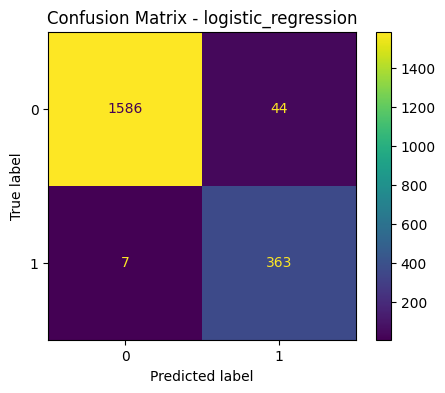

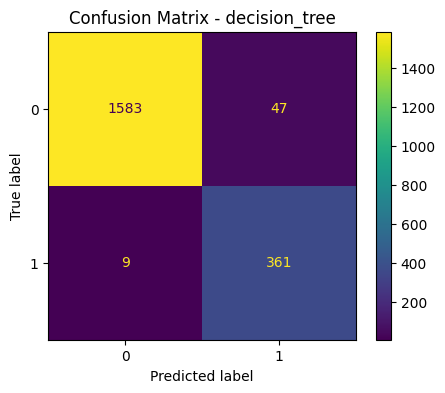

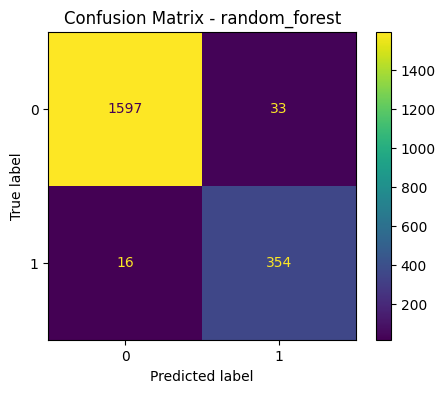

In [50]:
for model_name, artifacts in trained_artifacts.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        artifacts["y_pred"],
        ax=ax
    )
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.show()

## 11. Courbes ROC

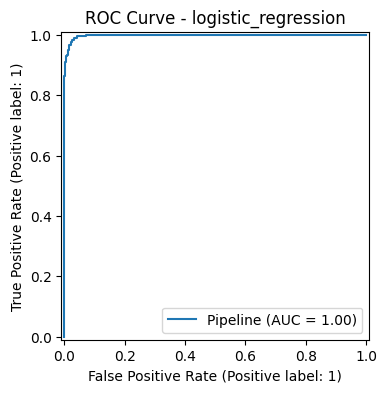

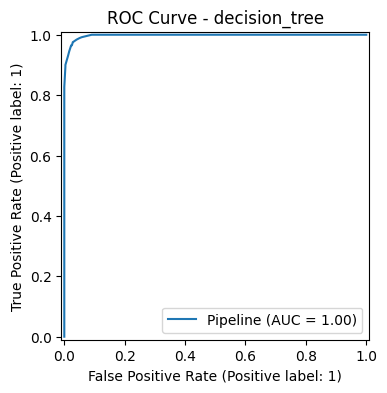

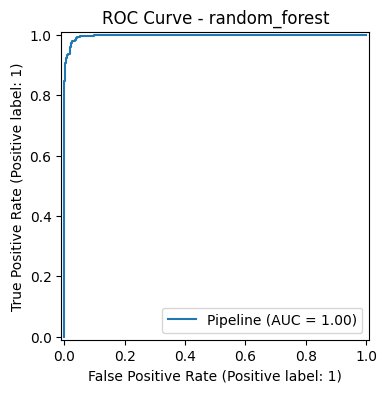

In [51]:
for model_name, artifacts in trained_artifacts.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    RocCurveDisplay.from_estimator(
        artifacts["best_model"],
        X_test,
        y_test,
        ax=ax
    )
    ax.set_title(f"ROC Curve - {model_name}")
    plt.show()

## 12. Courbes Precision-Recall

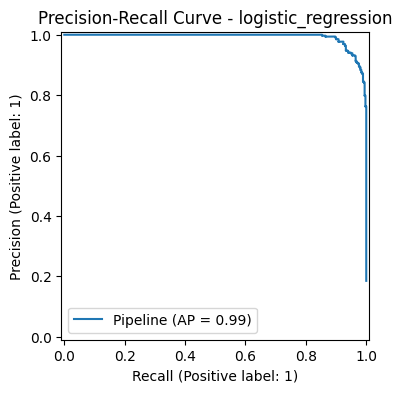

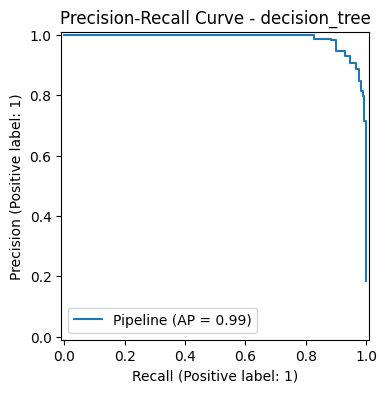

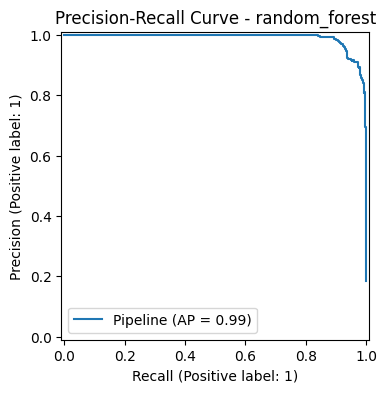

In [52]:
for model_name, artifacts in trained_artifacts.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    PrecisionRecallDisplay.from_estimator(
        artifacts["best_model"],
        X_test,
        y_test,
        ax=ax
    )
    ax.set_title(f"Precision-Recall Curve - {model_name}")
    plt.show()

## 13. Sélection du meilleur modèle et sauvegarde des artefacts

Le meilleur modèle est sélectionné selon `test_roc_auc`, puis `test_pr_auc` et `test_recall` en cas d'égalité.

On sauvegarde :
- le modèle final au format `.joblib` ;
- un fichier CSV de comparaison ;
- un fichier JSON avec les hyperparamètres retenus.

In [53]:
best_model_name = results_df.loc[0, "model"]
best_model = trained_artifacts[best_model_name]["best_model"]
best_params = results_df.loc[0, "best_params"]

print("Meilleur modèle sélectionné :", best_model_name)
print("Best params :", best_params)

joblib_path = ARTIFACTS_DIR / f"{best_model_name}_best_model.joblib"
csv_path = ARTIFACTS_DIR / "model_comparison_results.csv"
json_path = ARTIFACTS_DIR / f"{best_model_name}_best_params.json"

joblib.dump(best_model, joblib_path)
results_df.to_csv(csv_path, index=False)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False, default=str)

print("\nArtefacts sauvegardés :")
print("-", joblib_path)
print("-", csv_path)
print("-", json_path)

Meilleur modèle sélectionné : logistic_regression
Best params : {'model__C': 10.0, 'model__solver': 'lbfgs'}

Artefacts sauvegardés :
- C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\models\artifacts\logistic_regression_best_model.joblib
- C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\models\artifacts\model_comparison_results.csv
- C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\models\artifacts\logistic_regression_best_params.json


## 14. Interprétation métier du modèle retenu

Cette cellule génère une conclusion automatique réutilisable dans le rapport / la soutenance.

In [54]:
best_row = results_df.iloc[0]

print(
    f"""Le modèle retenu est **{best_row['model']}** car il présente la meilleure performance
sur le jeu de test selon notre critère principal de sélection (`ROC-AUC`), avec :
- ROC-AUC test : {best_row['test_roc_auc']:.4f}
- PR-AUC test  : {best_row['test_pr_auc']:.4f}
- Recall test  : {best_row['test_recall']:.4f}
- Precision test : {best_row['test_precision']:.4f}
- F1 test      : {best_row['test_f1']:.4f}

Ce choix est cohérent avec le contexte bancaire : l'objectif n'est pas seulement d'obtenir une bonne accuracy,
mais surtout de bien discriminer les profils à risque et de détecter un maximum de défauts potentiels.
"""
)

Le modèle retenu est **logistic_regression** car il présente la meilleure performance
sur le jeu de test selon notre critère principal de sélection (`ROC-AUC`), avec :
- ROC-AUC test : 0.9981
- PR-AUC test  : 0.9924
- Recall test  : 0.9811
- Precision test : 0.8919
- F1 test      : 0.9344

Ce choix est cohérent avec le contexte bancaire : l'objectif n'est pas seulement d'obtenir une bonne accuracy,
mais surtout de bien discriminer les profils à risque et de détecter un maximum de défauts potentiels.



## 15. Visualisation de MLflow

In [55]:
mlflow_summary_df = build_mlflow_summary_table()

if mlflow_summary_df.empty:
    print("Aucun run MLflow trouvé. Vérifie que les entraînements ont bien été exécutés.")
else:
    display(
        mlflow_summary_df[[
            "experiment_name",
            "run_name",
            "status",
            "test_roc_auc",
            "test_pr_auc",
            "test_recall",
            "test_precision",
            "test_f1"
        ]]
    )
    
mlflow_process, mlflow_url = launch_mlflow_ui(MLRUNS_DIR, port=5000, auto_open=True)
print(f"URL MLflow : {mlflow_url}")
print("Si le navigateur ne s'ouvre pas, copie-colle cette URL dans ton navigateur.")

[ERREUR] Impossible de lire les runs de l'experiment credit_default_random_forest: unacceptable character #x0000: control characters are not allowed
  in "C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\models\mlruns\501503879913269815\a32b6a9d84d54d79b47df894d9953fe2\meta.yaml", position 0
[ERREUR] Impossible de lire les runs de l'experiment credit_default_decision_tree: unacceptable character #x0000: control characters are not allowed
  in "C:\Users\PVeena\Desktop\Projet MLOPS\MLOPS_RETAIL_BANK\models\mlruns\425874716576126071\677acac225dd48c3bdf9d900060c758d\meta.yaml", position 0


,experiment_name,run_name,status,test_roc_auc,test_pr_auc,test_recall,test_precision,test_f1
0,credit_default_logistic_regression,logistic_regression_tuned,FINISHED,0.998121,0.992413,0.981081,0.891892,0.934363
1,credit_default_logistic_regression,logistic_regression_tuned,FINISHED,0.998121,0.992413,0.981081,0.891892,0.934363
2,credit_default_logistic_regression,logistic_regression_tuned,FINISHED,0.998121,0.992413,0.981081,0.891892,0.934363
3,credit_default_logistic_regression,logistic_regression_tuned,FINISHED,0.998121,0.992413,0.981081,0.891892,0.934363
4,credit_default_logistic_regression,logistic_regression_tuned,FINISHED,0.998121,0.992413,0.981081,0.891892,0.934363
5,credit_default_logistic_regression,logistic_regression_tuned,FINISHED,0.998121,0.992413,0.981081,0.891892,0.934363
6,credit_default_logistic_regression,logistic_regression_baseline,FINISHED,0.998093,0.992302,0.981081,0.878935,0.927203
7,credit_default_logistic_regression,logistic_regression_baseline,FINISHED,0.998093,0.992302,0.981081,0.878935,0.927203
8,credit_default_logistic_regression,logistic_regression_baseline,FINISHED,0.998093,0.992302,0.981081,0.878935,0.927203
9,credit_default_logistic_regression,logistic_regression_baseline,FINISHED,0.998093,0.992302,0.981081,0.878935,0.927203


MLflow UI lancé avec succès : http://127.0.0.1:5000
URL MLflow : http://127.0.0.1:5000
Si le navigateur ne s'ouvre pas, copie-colle cette URL dans ton navigateur.
